# NLP Sentiment Analysis — Complete Pipeline Demo

## 📘 Section 1: Introduction

### What is NLP?

**Natural Language Processing (NLP)** is a branch of artificial intelligence that enables computers to understand, interpret, and generate human language. It sits at the intersection of linguistics, computer science, and machine learning.

Common NLP tasks include:
- **Text classification** (spam detection, sentiment analysis)
- **Named Entity Recognition** (extracting people, places, organizations)
- **Machine translation** (English → French)
- **Text summarization** and **question answering**

### What is Sentiment Analysis?

**Sentiment Analysis** is the task of determining the emotional tone behind a piece of text — typically classifying it as **Positive**, **Negative**, or **Neutral**.

Applications:
- 📱 Product review analysis (Amazon, app stores)
- 🎬 Movie review aggregation (Rotten Tomatoes)
- 🐦 Social media monitoring (Twitter/X brand sentiment)
- 🏦 Customer feedback for banking and services

### Why Preprocessing Matters

Raw text is messy. It contains URLs, emojis, HTML tags, punctuation, numbers, and inconsistent casing. If we feed this directly into a model:

1. **Vocabulary explosion** — "Great", "great", "GREAT!" all become separate features
2. **Noise** — URLs and HTML tags carry no sentiment but inflate feature space
3. **Poor generalization** — the model learns noise patterns instead of sentiment

A good preprocessing pipeline:
- Normalizes text (lowercase, clean)
- Removes irrelevant noise (URLs, HTML, numbers)
- Reduces words to their root form (lemmatization: "running" → "run")
- Removes high-frequency low-information words (stop words)
- **Critically: retains negations** ("not good" ≠ "good")

### This Notebook

This notebook demonstrates the **complete NLP pipeline** for 3-class sentiment analysis (Positive / Neutral / Negative) on a custom dataset of ~2,000 product reviews.

**Roadmap:**
| Sections | Topic |
|----------|-------|
| 1–2 | Introduction & Setup |
| 3–4 | Load & Explore Dataset |
| 5–10 | Preprocessing Pipeline (step-by-step) |
| 11 | Feature Extraction (TF-IDF) |
| 12–14 | Train & Evaluate Models |
| 15–16 | Predict & Explain |
| 17–18 | Compare with Rule-Based Methods & Performance |
| 19–20 | Save Model & Conclusion |

> **Design note:** All preprocessing functions live in `preprocessing.py` — a standalone module designed to be reused later in a FastAPI backend with zero changes.

## 📦 Section 2: Install Libraries & Download Resources

This section ensures all required libraries are installed and NLP resources are downloaded.

**Libraries used:**
| Library | Purpose |
|---------|---------|
| `pandas` | Data manipulation (load CSV, explore) |
| `numpy` | Numerical operations |
| `nltk` | Tokenization, stop words, lemmatization resources |
| `spacy` | POS-aware lemmatization (better → well) |
| `matplotlib` | Charts (bar, pie, confusion matrix) |
| `scikit-learn` | TF-IDF, model training, evaluation |
| `wordcloud` | Word cloud visualization |
| `textblob` | Rule-based sentiment (polarity) |
| `vaderSentiment` | Rule-based sentiment (compound score) |

**NLTK resources downloaded:**
- `punkt`, `punkt_tab` — tokenizers
- `stopwords` — English stop words
- `wordnet`, `omw-1.4` — lemmatization dictionaries
- `vader_lexicon` — VADER sentiment lexicon

**spaCy model:** `en_core_web_sm` — small English model for lemmatization

In [1]:
# === Section 2: Install Libraries & Download Resources ===

import importlib
import subprocess
import sys

# --- 2.1 Auto-install missing packages ---
REQUIRED_PACKAGES = [
    "pandas", "numpy", "nltk", "spacy", "matplotlib",
    "sklearn", "wordcloud", "textblob", "vaderSentiment", "joblib",
]

missing = []
for pkg in REQUIRED_PACKAGES:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing)
    print("✓ All packages installed.")
else:
    print("✓ All required packages already installed.")

# --- 2.2 Download NLTK resources ---
import nltk

NLTK_RESOURCES = ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4", "vader_lexicon"]

for resource in NLTK_RESOURCES:
    try:
        if resource in ("punkt", "punkt_tab"):
            nltk.data.find(f"tokenizers/{resource}")
        elif resource == "stopwords":
            nltk.data.find("corpora/stopwords")
        elif resource in ("wordnet", "omw-1.4"):
            nltk.data.find(f"corpora/{resource}")
        elif resource == "vader_lexicon":
            nltk.data.find("sentiment/vader_lexicon")
        print(f"  ✓ NLTK '{resource}' already available")
    except LookupError:
        print(f"  ↓ Downloading NLTK '{resource}'...")
        nltk.download(resource, quiet=True)
        print(f"  ✓ NLTK '{resource}' downloaded")

# --- 2.3 Download spaCy model ---
import spacy

try:
    spacy.load("en_core_web_sm")
    print("  ✓ spaCy model 'en_core_web_sm' already available")
except OSError:
    print("  ↓ Downloading spaCy model 'en_core_web_sm'...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    print("  ✓ spaCy model 'en_core_web_sm' downloaded")

print("\n✅ All libraries and resources ready!")

✓ All required packages already installed.
  ✓ NLTK 'punkt' already available
  ✓ NLTK 'punkt_tab' already available
  ✓ NLTK 'stopwords' already available
  ↓ Downloading NLTK 'wordnet'...
  ✓ NLTK 'wordnet' downloaded
  ↓ Downloading NLTK 'omw-1.4'...
  ✓ NLTK 'omw-1.4' downloaded
  ↓ Downloading NLTK 'vader_lexicon'...
  ✓ NLTK 'vader_lexicon' downloaded
  ✓ spaCy model 'en_core_web_sm' already available

✅ All libraries and resources ready!


In [2]:
# --- 2.4 Import all libraries ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import spacy
import joblib
from collections import Counter

# scikit-learn imports (used in later sections)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Rule-based sentiment
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Word cloud
from wordcloud import WordCloud

# Our preprocessing module
import preprocessing as pp

# Display settings
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)

# Matplotlib inline
%matplotlib inline

print("✅ All imports successful!")
print(f"   pandas:      {pd.__version__}")
print(f"   numpy:       {np.__version__}")
print(f"   nltk:        {nltk.__version__}")
print(f"   spacy:       {spacy.__version__}")
print(f"   scikit-learn: {__import__('sklearn').__version__}")

✅ All imports successful!
   pandas:      3.0.3
   numpy:       2.1.3
   nltk:        3.9.4
   spacy:       3.8.14
   scikit-learn: 1.9.0


## 📂 Section 3: Load Dataset

We load the custom CSV dataset containing ~2,000 product reviews with 3 sentiment classes.

**Dataset format:**
| Column | Description |
|--------|-------------|
| `Review` | The review text (may contain URLs, emojis, HTML, numbers) |
| `Sentiment` | One of: `Positive`, `Neutral`, `Negative` |

The dataset was generated by `data/generate_dataset.py` with ~15% of reviews containing deliberate noise (URLs, emojis, HTML tags, numbers, extra spaces, ALL CAPS) to exercise every preprocessing function.

In [3]:
# === Section 3: Load Dataset ===

# Load the CSV file
df = pd.read_csv("data/reviews.csv")

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

# --- 3.1 First 10 rows ---
print("\n--- First 10 rows ---")
df.head(10)

DATASET LOADED

--- First 10 rows ---


,Review,Sentiment
0,This heater is a typical heater.,Neutral
1,The pillow is a great find.,Positive
2,This blender is wonderful and easy to use.,Positive
3,The desk is a forgettable deal.,Neutral
4,This charger is a piece of junk.,Negative
5,"Amazing mouse, highly recommend it.",Positive
6,I am very dissatisfied by this watch.,Negative
7,I am VERY impressed by this camera. 🙄,Positive
8,This microwave is a forgettable purchase.,Neutral
9,<i> THIS backpack is a total winner. 😐 <p>,Positive


In [4]:
# --- 3.2 Dataset shape ---
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# --- 3.3 Column names ---
print(f"Column names: {list(df.columns)}")

# --- 3.4 Missing values ---
print("\n--- Missing values per column ---")
print(df.isnull().sum())

# --- 3.5 Duplicate rows ---
num_duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {num_duplicates}")

# --- 3.6 Dataset statistics ---
print("\n--- Dataset info ---")
df.info()

print("\n--- Sentiment distribution ---")
print(df["Sentiment"].value_counts())

print("\n--- Review length statistics (characters) ---")
df["char_length"] = df["Review"].str.len()
print(df["char_length"].describe())

Dataset shape: 2001 rows × 2 columns
Column names: ['Review', 'Sentiment']

--- Missing values per column ---
Review       0
Sentiment    0
dtype: int64

Duplicate rows: 242

--- Dataset info ---
<class 'pandas.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Review     2001 non-null   str  
 1   Sentiment  2001 non-null   str  
dtypes: str(2)
memory usage: 31.4 KB

--- Sentiment distribution ---
Sentiment
Neutral     667
Positive    667
Negative    667
Name: count, dtype: int64

--- Review length statistics (characters) ---
count    2001.000000
mean       36.346827
std         9.684867
min        16.000000
25%        31.000000
50%        35.000000
75%        39.000000
max        93.000000
Name: char_length, dtype: float64


## 📊 Section 4: Explore Dataset

We visualize the class distribution and compute text statistics:
- **Bar chart** — count of each sentiment class
- **Pie chart** — proportion of each class
- **Average review length** — in characters and words
- **Longest & shortest review**
- **Vocabulary size** — total unique words across all reviews

--- Sentiment Class Counts ---
Sentiment
Neutral     667
Positive    667
Negative    667
Name: count, dtype: int64



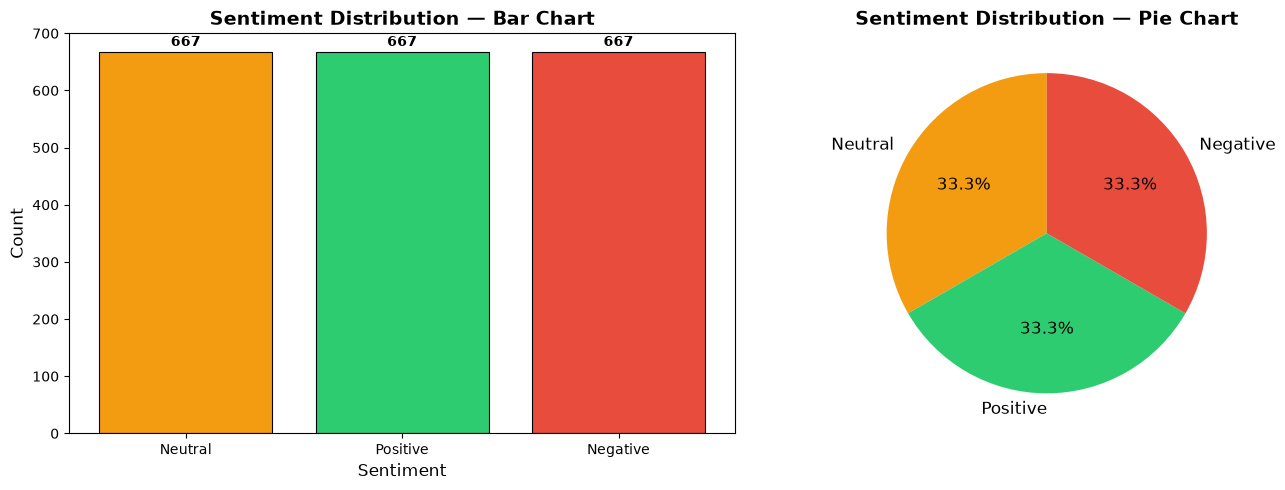

✓ Charts saved to outputs/sentiment_distribution.png


In [5]:
# === Section 4: Explore Dataset ===

# --- 4.1 Class counts ---
sentiment_counts = df["Sentiment"].value_counts()
print("--- Sentiment Class Counts ---")
print(sentiment_counts)
print()

# Define consistent colors for all charts
CLASS_COLORS = {
    "Positive": "#2ecc71",  # green
    "Neutral":  "#f39c12",  # orange
    "Negative": "#e74c3c",  # red
}
colors = [CLASS_COLORS[s] for s in sentiment_counts.index]

# --- 4.2 Bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_title("Sentiment Distribution — Bar Chart", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Sentiment", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
for i, (label, value) in enumerate(zip(sentiment_counts.index, sentiment_counts.values)):
    axes[0].text(i, value + 5, str(value), ha="center", va="bottom", fontweight="bold")

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, colors=colors,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Sentiment Distribution — Pie Chart", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Charts saved to outputs/sentiment_distribution.png")

--- Review Length Statistics ---
  Average length:    36.3 chars | 6.6 words
  Longest review:    93 chars
    → "<p> The  monitor  is a competent but basic item. </i> Visit https://www.productlink.com/page1..."
  Shortest review:   16 chars
    → "I hate this fan."

  Vocabulary size:   453 unique words (raw, before preprocessing)


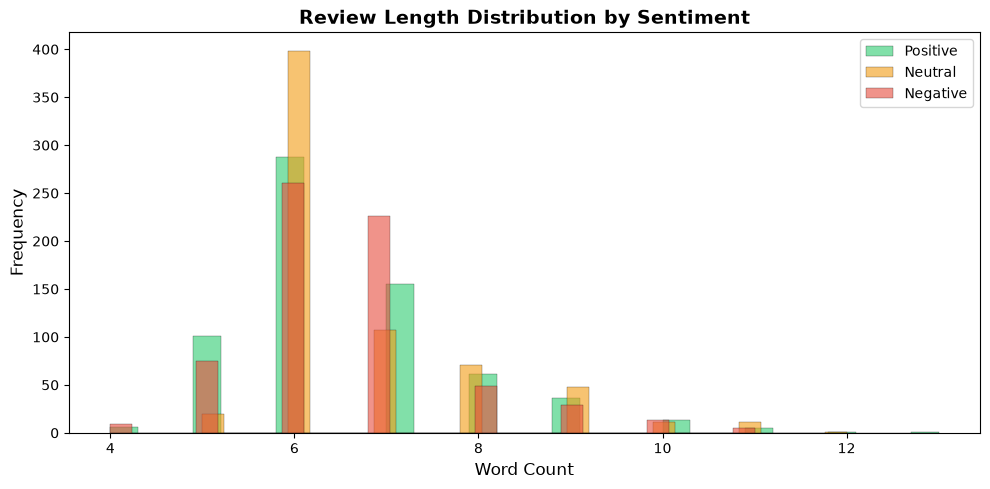

In [6]:
# --- 4.3 Review length statistics ---

# Word count per review
df["word_count"] = df["Review"].str.split().str.len()

avg_chars = df["char_length"].mean()
avg_words = df["word_count"].mean()
longest_idx = df["char_length"].idxmax()
shortest_idx = df["char_length"].idxmin()

print("--- Review Length Statistics ---")
print(f"  Average length:    {avg_chars:.1f} chars | {avg_words:.1f} words")
print(f"  Longest review:    {df.loc[longest_idx, 'char_length']} chars")
print(f"    → \"{df.loc[longest_idx, 'Review'][:100]}...\"")
print(f"  Shortest review:   {df.loc[shortest_idx, 'char_length']} chars")
print(f"    → \"{df.loc[shortest_idx, 'Review']}\"")

# --- 4.4 Vocabulary size ---
all_words = " ".join(df["Review"]).split()
vocabulary_size = len(set(all_words))
print(f"\n  Vocabulary size:   {vocabulary_size} unique words (raw, before preprocessing)")

# --- 4.5 Length distribution chart ---
fig, ax = plt.subplots(figsize=(10, 5))
for sentiment, color in CLASS_COLORS.items():
    subset = df[df["Sentiment"] == sentiment]
    ax.hist(subset["word_count"], bins=30, alpha=0.6, label=sentiment, color=color, edgecolor="black", linewidth=0.3)
ax.set_title("Review Length Distribution by Sentiment", fontsize=14, fontweight="bold")
ax.set_xlabel("Word Count", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

## 🔧 Section 5: NLP Preprocessing Pipeline

All preprocessing functions are defined in `preprocessing.py` — a standalone module that can be imported directly into a FastAPI backend later.

**Why a separate module?**
- Single source of truth (no duplication between notebook and API)
- Each function is stateless and testable
- The notebook displays the source code using `inspect.getsource()` so you can see the implementation inline

**The 12 preprocessing functions:**

| # | Function | Input → Output | Purpose |
|---|----------|----------------|---------|
| 1 | `lowercase()` | str → str | Normalize casing |
| 2 | `remove_urls()` | str → str | Remove http/https/www links |
| 3 | `remove_html()` | str → str | Remove HTML tags |
| 4 | `remove_emojis()` | str → str | Remove emoji characters |
| 5 | `remove_numbers()` | str → str | Remove standalone numbers |
| 6 | `remove_punctuation()` | str → str | Remove punctuation marks |
| 7 | `tokenize()` | str → list | Split into word tokens |
| 8 | `remove_stopwords()` | list → list | Remove stop words (keep negations!) |
| 9 | `lemmatize()` | list → list | Reduce to base form (spaCy POS-aware) |
| 10 | `remove_extra_spaces()` | str → str | Collapse whitespace |
| 11 | `clean_text()` | str → str | Full pipeline → clean string |
| 12 | `clean_text_tokens()` | str → list | Full pipeline → token list (for TF-IDF) |

In [7]:
# === Section 5: Display & Test Each Preprocessing Function ===

import inspect

# Test string with all noise types
test_text = "I REALLY Loved this Phone!!! 😊 Visit https://abc.com <br> 50%"

# List all functions to display and test
FUNCTIONS = [
    ("lowercase",            pp.lowercase,            test_text),
    ("remove_urls",          pp.remove_urls,          pp.lowercase(test_text)),
    ("remove_html",          pp.remove_html,          pp.remove_urls(pp.lowercase(test_text))),
    ("remove_emojis",        pp.remove_emojis,        pp.remove_html(pp.remove_urls(pp.lowercase(test_text)))),
    ("remove_numbers",       pp.remove_numbers,       pp.remove_emojis(pp.remove_html(pp.remove_urls(pp.lowercase(test_text))))),
    ("remove_punctuation",   pp.remove_punctuation,   pp.remove_emojis(pp.remove_html(pp.remove_urls(pp.lowercase(test_text))))),
    ("tokenize",             pp.tokenize,             pp.remove_extra_spaces(pp.remove_punctuation(pp.remove_emojis(pp.remove_html(pp.remove_urls(pp.lowercase(test_text))))))),
    ("remove_stopwords",     pp.remove_stopwords,     pp.tokenize(pp.remove_extra_spaces(pp.remove_punctuation(pp.remove_emojis(pp.remove_html(pp.remove_urls(pp.lowercase(test_text)))))))),
    ("lemmatize",            pp.lemmatize,            pp.remove_stopwords(pp.tokenize(pp.remove_extra_spaces(pp.remove_punctuation(pp.remove_emojis(pp.remove_html(pp.remove_urls(pp.lowercase(test_text))))))))),
    ("remove_extra_spaces",  pp.remove_extra_spaces,  pp.remove_punctuation(pp.remove_emojis(pp.remove_html(pp.remove_urls(pp.lowercase(test_text)))))),
]

for name, func, test_input in FUNCTIONS:
    print(f"\n{'='*60}")
    print(f"FUNCTION: {name}()")
    print(f"{'='*60}")
    print(f"\n--- Source code ---")
    print(inspect.getsource(func))
    print(f"--- Test ---")
    print(f"  Input:  {repr(test_input)}")
    result = func(test_input)
    print(f"  Output: {repr(result)}")


FUNCTION: lowercase()

--- Source code ---
def lowercase(text: str) -> str:
    """
    Convert all characters in the text to lowercase.

    Why: Ensures uniformity — 'Great' and 'great' are treated as the same word.
    Without this, the model would see them as two different features.

    Args:
        text: Raw input string.

    Returns:
        Lowercased string.
    """
    return text.lower()

--- Test ---
  Input:  'I REALLY Loved this Phone!!! 😊 Visit https://abc.com <br> 50%'
  Output: 'i really loved this phone!!! 😊 visit https://abc.com <br> 50%'

FUNCTION: remove_urls()

--- Source code ---
def remove_urls(text: str) -> str:
    """
    Remove URLs (http, https, www) from the text.

    Why: URLs carry no sentiment information and add noise to the vocabulary.

    Args:
        text: Input string (ideally already lowercased).

    Returns:
        String with URLs removed.
    """
    url_pattern = re.compile(r"https?://\S+|www\.\S+")
    return url_pattern.sub("", text)

## 🔄 Section 6: Step-by-Step Preprocessing Demo

We take one noisy review and apply each preprocessing function **one at a time**, printing the output after every step. This makes the transformation pipeline fully visible.

**Sample review:**
> `"I REALLY Loved this Phone!!! 😊 Visit https://abc.com"`

This review contains:
- ✅ Mixed case (REALLY, Loved)
- ✅ Punctuation (!!!)
- ✅ Emoji (😊)
- ✅ URL (https://abc.com)

In [8]:
# === Section 6: Step-by-Step Preprocessing Demo ===

sample = "I REALLY Loved this Phone!!! 😊 Visit https://abc.com"

print(f"Raw Review:\n  \"{sample}\"")
print("↓")

# Step 1: Lowercase
step1 = pp.lowercase(sample)
print(f"\n1. Lowercase:\n  \"{step1}\"")
print("↓")

# Step 2: Remove URLs
step2 = pp.remove_urls(step1)
print(f"\n2. URL Removed:\n  \"{step2}\"")
print("↓")

# Step 3: Remove HTML (none in this sample, but show for completeness)
step3 = pp.remove_html(step2)
print(f"\n3. HTML Removed:\n  \"{step3}\"")
print("↓")

# Step 4: Remove Emojis
step4 = pp.remove_emojis(step3)
print(f"\n4. Emoji Removed:\n  \"{step4}\"")
print("↓")

# Step 5: Remove Numbers (none in this sample)
step5 = pp.remove_numbers(step4)
print(f"\n5. Numbers Removed:\n  \"{step5}\"")
print("↓")

# Step 6: Remove Punctuation
step6 = pp.remove_punctuation(step5)
print(f"\n6. Punctuation Removed:\n  \"{step6}\"")
print("↓")

# Step 7: Remove Extra Spaces
step7 = pp.remove_extra_spaces(step6)
print(f"\n7. Extra Spaces Removed:\n  \"{step7}\"")
print("↓")

# Step 8: Tokenize
step8 = pp.tokenize(step7)
print(f"\n8. Tokens:\n  {step8}")
print("↓")

# Step 9: Remove Stop Words
step9 = pp.remove_stopwords(step8)
print(f"\n9. Stop Words Removed:\n  {step9}")
print("↓")

# Step 10: Lemmatize
step10 = pp.lemmatize(step9)
print(f"\n10. Lemmatized:\n  {step10}")
print("↓")

# Final
final_text = " ".join(step10)
print(f"\n✅ Final Clean Text:\n  \"{final_text}\"")

# Also show the one-liner
print(f"\n--- Using clean_text() (one call) ---")
print(f"  \"{pp.clean_text(sample)}\"")
print(f"\n--- Using clean_text_tokens() (one call) ---")
print(f"  {pp.clean_text_tokens(sample)}")

Raw Review:
  "I REALLY Loved this Phone!!! 😊 Visit https://abc.com"
↓

1. Lowercase:
  "i really loved this phone!!! 😊 visit https://abc.com"
↓

2. URL Removed:
  "i really loved this phone!!! 😊 visit "
↓

3. HTML Removed:
  "i really loved this phone!!! 😊 visit "
↓

4. Emoji Removed:
  "i really loved this phone!!!  visit "
↓

5. Numbers Removed:
  "i really loved this phone!!!  visit "
↓

6. Punctuation Removed:
  "i really loved this phone  visit "
↓

7. Extra Spaces Removed:
  "i really loved this phone visit"
↓

8. Tokens:
  ['i', 'really', 'loved', 'this', 'phone', 'visit']
↓

9. Stop Words Removed:
  ['really', 'loved', 'phone', 'visit']
↓

10. Lemmatized:
  ['really', 'love', 'phone', 'visit']
↓

✅ Final Clean Text:
  "really love phone visit"

--- Using clean_text() (one call) ---
  "really love phone visit"

--- Using clean_text_tokens() (one call) ---
  ['really', 'love', 'phone', 'visit']


## 📝 Section 7: Token Visualization

We compare **original tokens** (raw split) vs **processed tokens** (after full pipeline) for a sample review.

We also visualize **token frequency** — the most common words across all reviews.

In [9]:
# === Section 7: Token Visualization ===

# Pick a sample review
sample_review = df.iloc[0]["Review"]
print(f"Sample review: \"{sample_review}\"")

# Original tokens (simple split)
original_tokens = sample_review.split()
print(f"\n--- Original Tokens ({len(original_tokens)} words) ---")
print(original_tokens)

# Processed tokens (full pipeline)
processed_tokens = pp.clean_text_tokens(sample_review)
print(f"\n--- Processed Tokens ({len(processed_tokens)} words) ---")
print(processed_tokens)

# Unique words
original_unique = set(original_tokens)
processed_unique = set(processed_tokens)
print(f"\n--- Unique Words ---")
print(f"  Original:  {len(original_unique)} unique words")
print(f"  Processed: {len(processed_unique)} unique words")

# Word count comparison
print(f"\n--- Word Count ---")
print(f"  Original:  {len(original_tokens)} words")
print(f"  Processed: {len(processed_tokens)} words")
print(f"  Removed:   {len(original_tokens) - len(processed_tokens)} words ({(1 - len(processed_tokens)/len(original_tokens))*100:.0f}% reduction)")

Sample review: "This heater is a typical heater."

--- Original Tokens (6 words) ---
['This', 'heater', 'is', 'a', 'typical', 'heater.']

--- Processed Tokens (3 words) ---
['heater', 'typical', 'heater']

--- Unique Words ---
  Original:  6 unique words
  Processed: 2 unique words

--- Word Count ---
  Original:  6 words
  Processed: 3 words
  Removed:   3 words (50% reduction)


Processing all reviews for frequency analysis...
Total processed tokens: 6530
Unique processed tokens: 232

--- Top 20 Most Frequent Words (after preprocessing) ---
  bad                  →  349
  forgettable          →  311
  purchase             →  146
  overall              →  130
  buy                  →  125
  visit                →  106
  option               →  105
  choice               →  103
  great                →   96
  item                 →   94
  deal                 →   85
  watch                →   85
  headphone            →   82
  webcam               →   82
  camera               →   81
  heater               →   80
  router               →   77
  device               →   75
  model                →   74
  fan                  →   74


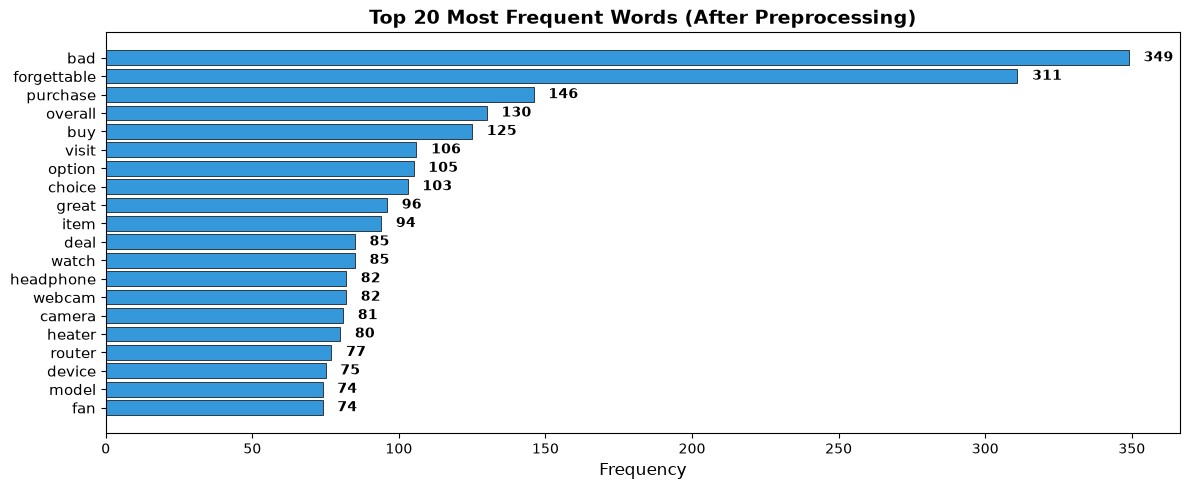

In [10]:
# --- 7.2 Token Frequency (top 20 across all reviews) ---

# Process all reviews and collect tokens
print("Processing all reviews for frequency analysis...")
all_processed_tokens = []
for review in df["Review"]:
    tokens = pp.clean_text_tokens(review)
    all_processed_tokens.extend(tokens)

print(f"Total processed tokens: {len(all_processed_tokens)}")
print(f"Unique processed tokens: {len(set(all_processed_tokens))}")

# Frequency distribution
from nltk import FreqDist
fdist = FreqDist(all_processed_tokens)
top_20 = fdist.most_common(20)

print(f"\n--- Top 20 Most Frequent Words (after preprocessing) ---")
for word, count in top_20:
    print(f"  {word:20s} → {count:4d}")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
words, counts = zip(*top_20)
ax.barh(range(len(words)), counts, color="#3498db", edgecolor="black", linewidth=0.5)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Frequency", fontsize=12)
ax.set_title("Top 20 Most Frequent Words (After Preprocessing)", fontsize=14, fontweight="bold")
for i, count in enumerate(counts):
    ax.text(count + 5, i, str(count), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 🛑 Section 8: Stop Word Visualization

**What are stop words?**  
Stop words are high-frequency words that appear in almost every sentence: *the, is, at, which, on, this, a, an...*

**Why remove them?**
- They carry little sentiment information
- They inflate the feature space
- They make the model focus on meaningful words

**⚠️ Critical: Negations are RETAINED!**  
Words like **not, no, never, n't, nor, none** are NOT removed because they **flip sentiment**:
- "good" → Positive
- "not good" → Negative
- "happy" → Positive
- "not happy" → Negative

If we removed "not", both "good" and "not good" would look identical to the model!

In [11]:
# === Section 8: Stop Word Visualization ===

from nltk.corpus import stopwords as nltk_stopwords

# Show the stop words that NLTK removes
stop_words = set(nltk_stopwords.words("english"))
print(f"Total NLTK English stop words: {len(stop_words)}")
print(f"\nSample stop words: {sorted(list(stop_words))[:20]}...")

# Show which negation words we KEEP
negations_kept = pp.NEGATION_WORDS & stop_words
print(f"\n⚠️  Negation words RETAINED (not removed): {sorted(negations_kept)}")

# --- 8.1 Demonstrate on a sample with negation ---
neg_sample = "This phone is not good and I do not like it at all"
print(f"\n--- Negation Demo ---")
print(f"  Input:           \"{neg_sample}\"")
tokens = pp.tokenize(pp.remove_punctuation(pp.lowercase(neg_sample)))
print(f"  Tokens:          {tokens}")
filtered = pp.remove_stopwords(tokens)
print(f"  After stopword:  {filtered}")
print(f"  ✓ 'not' is kept! → sentiment is preserved")

Total NLTK English stop words: 198

Sample stop words: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']...

⚠️  Negation words RETAINED (not removed): ['no', 'nor', 'not']

--- Negation Demo ---
  Input:           "This phone is not good and I do not like it at all"
  Tokens:          ['this', 'phone', 'is', 'not', 'good', 'and', 'i', 'do', 'not', 'like', 'it', 'at', 'all']
  After stopword:  ['phone', 'not', 'good', 'not', 'like']
  ✓ 'not' is kept! → sentiment is preserved


Demo review: "This is not a great product and I do not recommend it to anyone"

  All tokens:    ['this', 'is', 'not', 'a', 'great', 'product', 'and', 'i', 'do', 'not', 'recommend', 'it', 'to', 'anyone']
  Removed (stop): ['this', 'is', 'a', 'and', 'i', 'do', 'it', 'to']
  Remaining:      ['not', 'great', 'product', 'not', 'recommend', 'anyone']


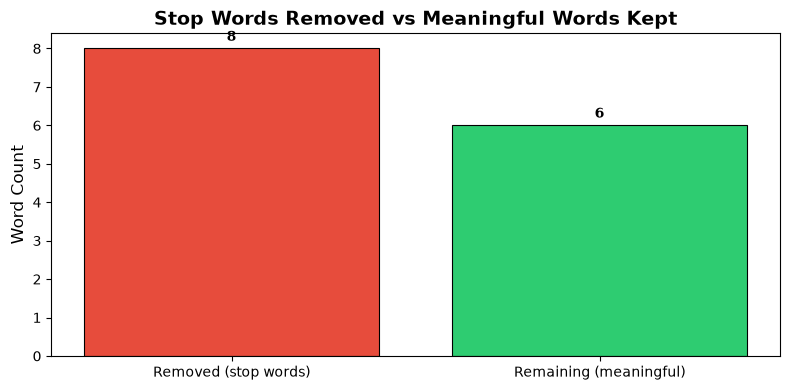


  Words removed: ['this', 'is', 'a', 'and', 'i', 'do', 'it', 'to']
  Words kept:    ['not', 'great', 'product', 'not', 'recommend', 'anyone']

  💡 Notice: 'not' and 'do not' are KEPT because they carry sentiment!


In [12]:
# --- 8.2 Visualize removed vs remaining words ---

# Take a sample review and show what was removed vs kept
demo_review = "This is not a great product and I do not recommend it to anyone"
print(f"Demo review: \"{demo_review}\"")

raw_tokens = pp.tokenize(pp.remove_punctuation(pp.lowercase(demo_review)))
kept_tokens = pp.remove_stopwords(raw_tokens)
removed_tokens = [t for t in raw_tokens if t not in kept_tokens]

print(f"\n  All tokens:    {raw_tokens}")
print(f"  Removed (stop): {removed_tokens}")
print(f"  Remaining:      {kept_tokens}")

# Bar chart: removed vs remaining
fig, ax = plt.subplots(figsize=(8, 4))
categories = ["Removed (stop words)", "Remaining (meaningful)"]
values = [len(removed_tokens), len(kept_tokens)]
colors_bar = ["#e74c3c", "#2ecc71"]
ax.bar(categories, values, color=colors_bar, edgecolor="black", linewidth=0.8)
ax.set_ylabel("Word Count", fontsize=12)
ax.set_title("Stop Words Removed vs Meaningful Words Kept", fontsize=14, fontweight="bold")
for i, v in enumerate(values):
    ax.text(i, v + 0.2, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# Show the actual removed words
print(f"\n  Words removed: {removed_tokens}")
print(f"  Words kept:    {kept_tokens}")
print(f"\n  💡 Notice: 'not' and 'do not' are KEPT because they carry sentiment!")

## 🌱 Section 9: Lemmatization Demo

**Lemmatization** converts words to their base dictionary form (lemma).

| Word | Lemma | Why |
|------|-------|-----|
| running | run | verb → base form |
| cars | car | plural → singular |
| loved | love | past tense → base |
| better | well | comparative → base (POS-aware!) |
| studies | study | plural verb → base |

**Lemmatization vs Stemming:**
- **Stemming** (Porter): crude chopping — "running" → "run", but "better" → "better" (can't handle irregulars)
- **Lemmatization** (spaCy): dictionary-aware, POS-aware — "better" → "well", "mice" → "mouse"

We use **spaCy** for lemmatization because it's POS-aware and handles irregular forms correctly.

In [13]:
# === Section 9: Lemmatization Demo ===

# Test words that demonstrate lemmatization power
lemmatize_tests = [
    ("running",  "run"),     # verb → base
    ("cars",     "car"),     # plural → singular
    ("loved",    "love"),    # past tense → base
    ("better",   "well"),    # comparative → base (POS-aware!)
    ("studies",  "study"),   # plural verb → base
    ("mice",     "mouse"),   # irregular plural → singular
    ("feet",     "foot"),    # irregular plural → singular
    ("children", "child"),   # irregular plural → singular
    ("went",     "go"),      # irregular past tense → base
    ("best",     "good"),    # superlative → base (POS-aware!)
]

print(f"{'Word':<15} {'Expected':<15} {'spaCy Lemma':<15} {'Match?'}")
print("-" * 55)

for word, expected in lemmatize_tests:
    result = pp.lemmatize([word])
    lemma = result[0] if result else "(empty)"
    match = "✓" if lemma == expected else "✗"
    print(f"{word:<15} {expected:<15} {lemma:<15} {match}")

print("\n💡 spaCy uses POS (part-of-speech) tagging to handle irregular forms")
print("   like 'better' → 'well' and 'went' → 'go' that stemming cannot do.")

Word            Expected        spaCy Lemma     Match?
-------------------------------------------------------
running         run             run             ✓
cars            car             car             ✓
loved           love            love            ✓
better          well            well            ✓
studies         study           study           ✓
mice            mouse           mouse           ✓
feet            foot            foot            ✓
children        child           child           ✓
went            go              go              ✓
best            good            well            ✗

💡 spaCy uses POS (part-of-speech) tagging to handle irregular forms
   like 'better' → 'well' and 'went' → 'go' that stemming cannot do.


## ☁️ Section 10: Word Clouds

Word clouds visualize the most frequent words in each sentiment class. Larger words appear more frequently.

We generate 3 word clouds:
- 🟢 **Positive** reviews
- 🟠 **Neutral** reviews
- 🔴 **Negative** reviews

All text is preprocessed before generating the cloud (stop words removed, lemmatized).

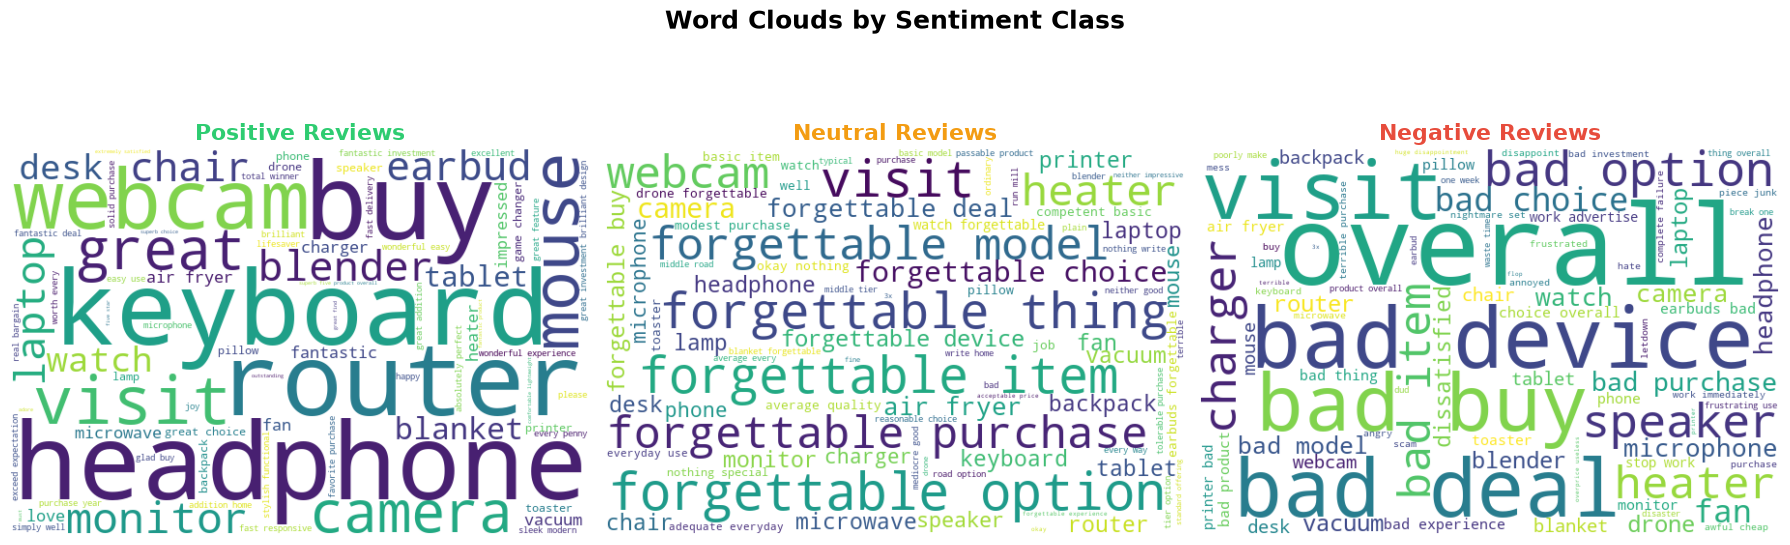

✓ Word clouds saved to outputs/wordcloud_positive.png, wordcloud_neutral.png, wordcloud_negative.png


In [14]:
# === Section 10: Word Clouds ===

# Preprocess all reviews by sentiment class
def get_cleaned_text_by_class(sentiment_label):
    """Return all cleaned text for a given sentiment class as a single string."""
    reviews = df[df["Sentiment"] == sentiment_label]["Review"].tolist()
    cleaned = [pp.clean_text(r) for r in reviews]
    return " ".join(cleaned)

# Generate word clouds
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (sentiment, color) in zip(axes, CLASS_COLORS.items()):
    text = get_cleaned_text_by_class(sentiment)

    wc = WordCloud(
        width=600, height=400,
        background_color="white",
        colormap=None,
        max_words=80,
        contour_width=2,
        contour_color=color,
        random_state=42,
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{sentiment} Reviews", fontsize=16, fontweight="bold", color=color)
    ax.axis("off")

    # Save individual word cloud
    wc.to_file(f"outputs/wordcloud_{sentiment.lower()}.png")

plt.suptitle("Word Clouds by Sentiment Class", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("✓ Word clouds saved to outputs/wordcloud_positive.png, wordcloud_neutral.png, wordcloud_negative.png")

## 📐 Section 11: TF-IDF Feature Extraction

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts text into numerical vectors that ML models can process.

### How it works:

**TF (Term Frequency):** How often a word appears in a review.
$$TF(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total words in } d}$$

**IDF (Inverse Document Frequency):** How rare a word is across all reviews. Common words get low weight; rare words get high weight.
$$IDF(t) = \log\frac{N}{\text{number of reviews containing } t}$$

**TF-IDF:** The product — high weight for words that are frequent in a review but rare across the corpus.
$$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$$

### Why TF-IDF (not raw counts)?
- "the" appears in every review → low IDF → low weight (correct!)
- "fantastic" appears in few reviews → high IDF → high weight (correct!)
- Captures the **distinctiveness** of words

In [15]:
# === Section 11: TF-IDF Feature Extraction ===

# Create TF-IDF vectorizer using our custom preprocessing tokenizer
# clean_text_tokens() is used as the tokenizer — it applies the full pipeline
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=pp.clean_text_tokens,
    token_pattern=None,   # required when using custom tokenizer
    max_features=5000,    # limit vocabulary to top 5000 words
    ngram_range=(1, 1),   # unigrams only (could use (1,2) for bigrams)
)

# Fit and transform all reviews
print("Fitting TF-IDF vectorizer on all reviews...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df["Review"])

print(f"\n--- TF-IDF Matrix ---")
print(f"  Matrix shape:     {tfidf_matrix.shape}  (reviews × features)")
print(f"  Vocabulary size:  {len(tfidf_vectorizer.vocabulary_)} words")
print(f"  Matrix density:   {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}  (fraction of non-zero entries)")

# --- 11.1 Show vocabulary (first 20 words) ---
print(f"\n--- Vocabulary sample (first 20 words) ---")
vocab_sorted = sorted(tfidf_vectorizer.vocabulary_.items(), key=lambda x: x[1])
for word, idx in vocab_sorted[:20]:
    print(f"  {word:20s} → index {idx}")

Fitting TF-IDF vectorizer on all reviews...

--- TF-IDF Matrix ---
  Matrix shape:     (2001, 232)  (reviews × features)
  Vocabulary size:  232 words
  Matrix density:   0.0140  (fraction of non-zero entries)

--- Vocabulary sample (first 20 words) ---
  2nd                  → index 0
  3x                   → index 1
  absolutely           → index 2
  acceptable           → index 3
  addition             → index 4
  adequate             → index 5
  adore                → index 6
  advertise            → index 7
  air                  → index 8
  amazing              → index 9
  angry                → index 10
  annoy                → index 11
  annoyed              → index 12
  average              → index 13
  away                 → index 14
  awful                → index 15
  backpack             → index 16
  bad                  → index 17
  bargain              → index 18
  basic                → index 19


--- Top 20 Words by TF-IDF Score (sum across all reviews) ---
  bad                  → 132.352
  forgettable          → 129.979
  purchase             → 69.495
  overall              → 62.209
  buy                  → 61.865
  option               → 55.607
  choice               → 55.128
  item                 → 50.752
  deal                 → 49.817
  visit                → 45.555
  great                → 45.172
  device               → 44.899
  watch                → 43.990
  model                → 43.593
  headphone            → 41.511
  webcam               → 41.395
  heater               → 41.163
  camera               → 41.101
  router               → 40.114
  charger              → 37.705


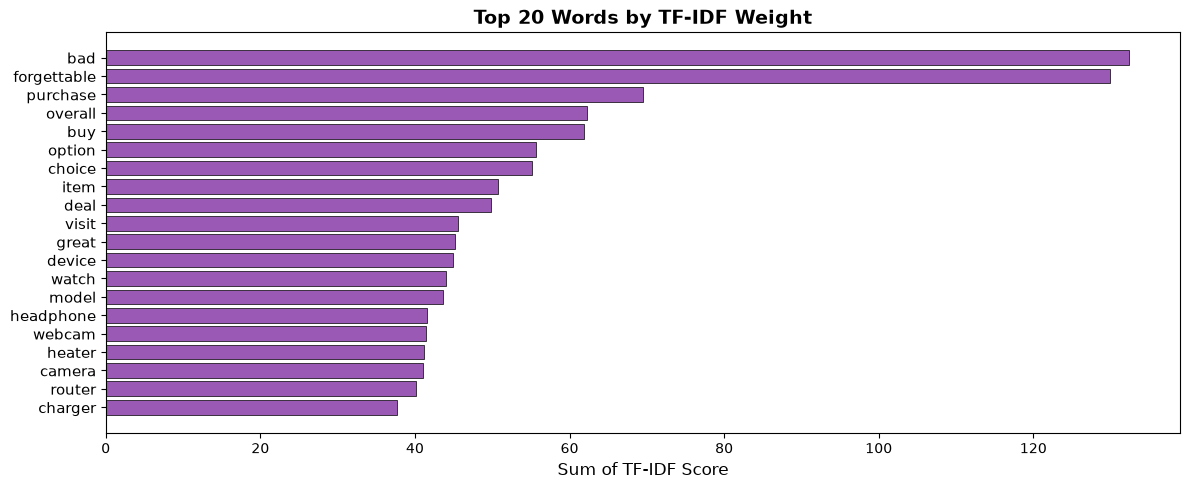

In [17]:
# --- 11.2 Top weighted words (highest sum of TF-IDF across all reviews) ---

# Sum TF-IDF scores for each word across all documents
word_scores = {}
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_array = tfidf_matrix.toarray()

for idx in range(len(feature_names)):
    word_scores[feature_names[idx]] = tfidf_array[:, idx].sum()

# Sort by score
top_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:20]

print("--- Top 20 Words by TF-IDF Score (sum across all reviews) ---")
for word, score in top_words:
    print(f"  {word:20s} → {score:.3f}")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
words, scores = zip(*top_words)
ax.barh(range(len(words)), scores, color="#9b59b6", edgecolor="black", linewidth=0.5)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Sum of TF-IDF Score", fontsize=12)
ax.set_title("Top 20 Words by TF-IDF Weight", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# --- 11.3 Show one review's TF-IDF vector ---

# Pick the first review
review_idx = 0
review_text = df.iloc[review_idx]["Review"]
review_vector = tfidf_matrix[review_idx]

print(f"Review #{review_idx}: \"{review_text}\"")
print(f"\n--- Non-zero TF-IDF entries for this review ---")

# Get non-zero entries
nonzero_indices = review_vector.nonzero()[1]
nonzero_scores = review_vector.toarray()[0][nonzero_indices]

# Sort by score descending
sorted_pairs = sorted(zip(nonzero_indices, nonzero_scores), key=lambda x: x[1], reverse=True)

for idx, score in sorted_pairs:
    word = feature_names[idx]
    print(f"  {word:20s} → TF-IDF: {score:.4f}")

print(f"\n  Total non-zero features: {len(sorted_pairs)} out of {tfidf_matrix.shape[1]}")

Review #0: "This heater is a typical heater."

--- Non-zero TF-IDF entries for this review ---
  heater               → TF-IDF: 0.8074
  typical              → TF-IDF: 0.5900

  Total non-zero features: 2 out of 232


## ✂️ Section 12: Train/Test Split

We split the data into:
- **80% Training set** — used to train the models
- **20% Test set** — used to evaluate on unseen data

**Key settings:**
- `random_state=42` — for reproducibility
- `stratify=y` — ensures the same class proportion in train and test

In [19]:
# === Section 12: Train/Test Split ===

# Features (TF-IDF matrix) and labels
X = tfidf_matrix
y = df["Sentiment"]

# 80/20 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("--- Train/Test Split ---")
print(f"  Training set:  {X_train.shape[0]} reviews ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"  Test set:      {X_test.shape[0]} reviews ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"  Features:      {X_train.shape[1]}")

# Verify stratification
print(f"\n--- Class distribution in Train set ---")
print(y_train.value_counts().sort_index())
print(f"\n--- Class distribution in Test set ---")
print(y_test.value_counts().sort_index())

--- Train/Test Split ---
  Training set:  1600 reviews (80%)
  Test set:      401 reviews (20%)
  Features:      232

--- Class distribution in Train set ---
Sentiment
Negative    534
Neutral     533
Positive    533
Name: count, dtype: int64

--- Class distribution in Test set ---
Sentiment
Negative    133
Neutral     134
Positive    134
Name: count, dtype: int64


## 🤖 Section 13: Train Models

We train **3 different models** and compare them:

| Model | Type | Strengths |
|-------|------|-----------|
| **Logistic Regression** | Linear | Fast, interpretable coefficients, good baseline |
| **Multinomial Naive Bayes** | Probabilistic | Great for text, assumes word independence |
| **Linear SVM** (LinearSVC) | Margin-based | Strong accuracy, wrapped in `CalibratedClassifierCV` for probabilities |

All models operate on the TF-IDF vectors from Section 11.

In [20]:
# === Section 13: Train Models ===

import time

# Define models
models = {}

# 1. Logistic Regression
print("Training Logistic Regression...")
t0 = time.perf_counter()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_time = time.perf_counter() - t0
models["Logistic Regression"] = lr_model
print(f"  ✓ Trained in {lr_time:.3f}s")

# 2. Multinomial Naive Bayes
print("Training Multinomial Naive Bayes...")
t0 = time.perf_counter()
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_time = time.perf_counter() - t0
models["Naive Bayes"] = nb_model
print(f"  ✓ Trained in {nb_time:.3f}s")

# 3. Linear SVM (wrapped in CalibratedClassifierCV for probabilities)
print("Training Linear SVM (with calibration)...")
t0 = time.perf_counter()
svm_base = LinearSVC(random_state=42, max_iter=10000, dual="auto")
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train, y_train)
svm_time = time.perf_counter() - t0
models["Linear SVM"] = svm_model
print(f"  ✓ Trained in {svm_time:.3f}s")

# --- 13.1 Compare training accuracy ---
print(f"\n{'='*50}")
print(f"{'Model':<25} {'Train Acc':>10} {'Train Time':>12}")
print(f"{'='*50}")

for name, model in models.items():
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    train_t = {"Logistic Regression": lr_time, "Naive Bayes": nb_time, "Linear SVM": svm_time}[name]
    print(f"{name:<25} {train_acc:>10.4f} {train_t:>11.3f}s")

print(f"{'='*50}")

Training Logistic Regression...
  ✓ Trained in 0.021s
Training Multinomial Naive Bayes...
  ✓ Trained in 0.002s
Training Linear SVM (with calibration)...
  ✓ Trained in 0.035s

Model                      Train Acc   Train Time
Logistic Regression           0.9975       0.021s
Naive Bayes                   0.9944       0.002s
Linear SVM                    1.0000       0.035s


## 📏 Section 14: Model Evaluation

We evaluate each model on the **test set** using:

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | $\frac{TP + TN}{Total}$ | Overall correctness |
| **Precision** (macro) | $\frac{TP}{TP + FP}$ | Per-class, averaged |
| **Recall** (macro) | $\frac{TP}{TP + FN}$ | Per-class, averaged |
| **F1** (macro) | $2 \times \frac{P \times R}{P + R}$ | Harmonic mean of P and R |

We also show:
- **Classification report** — per-class precision, recall, F1
- **Confusion matrix** — visual heatmap of predictions vs actual

> **Note on ROC curve:** ROC curves are designed for **binary** classification. Since we have 3 classes (Positive/Neutral/Negative), we show a **per-class precision/recall bar chart** instead. To extend to binary, simply filter to 2 classes.

In [21]:
# === Section 14: Model Evaluation ===

# Evaluate all models on test set
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
    })

# Display comparison table
results_df = pd.DataFrame(results)
print("--- Model Comparison (Test Set) ---")
print(results_df.to_string(index=False, float_format="%.4f"))

# Find best model
best_model_name = results_df.loc[results_df["F1"].idxmax(), "Model"]
best_model = models[best_model_name]
print(f"\n🏆 Best model by F1 score: {best_model_name}")

--- Model Comparison (Test Set) ---
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.9975     0.9975  0.9975 0.9975
        Naive Bayes    0.9925     0.9926  0.9925 0.9925
         Linear SVM    1.0000     1.0000  1.0000 1.0000

🏆 Best model by F1 score: Linear SVM


In [22]:
# --- 14.1 Classification Report for best model ---

print(f"--- Classification Report: {best_model_name} ---\n")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, zero_division=0))

--- Classification Report: Linear SVM ---

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       133
     Neutral       1.00      1.00      1.00       134
    Positive       1.00      1.00      1.00       134

    accuracy                           1.00       401
   macro avg       1.00      1.00      1.00       401
weighted avg       1.00      1.00      1.00       401



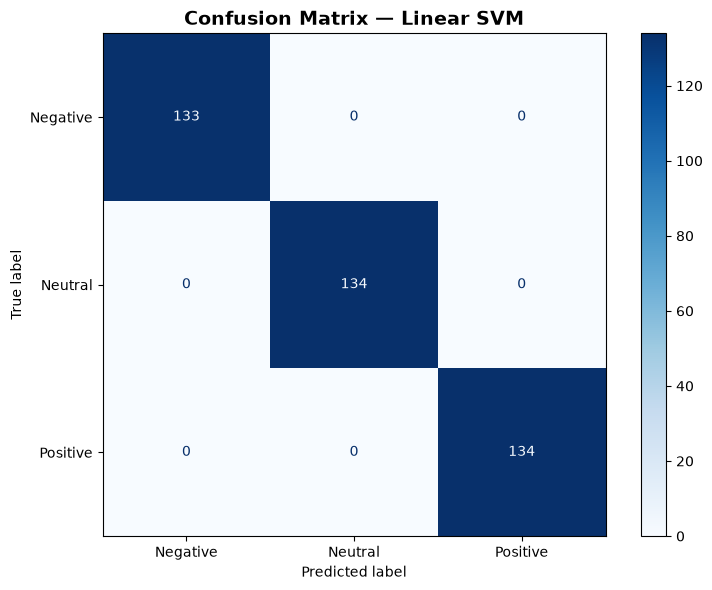

✓ Confusion matrix saved to outputs/confusion_matrix.png


In [23]:
# --- 14.2 Confusion Matrix (heatmap) ---

cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues", ax=ax, values_format="d")
ax.set_title(f"Confusion Matrix — {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Confusion matrix saved to outputs/confusion_matrix.png")

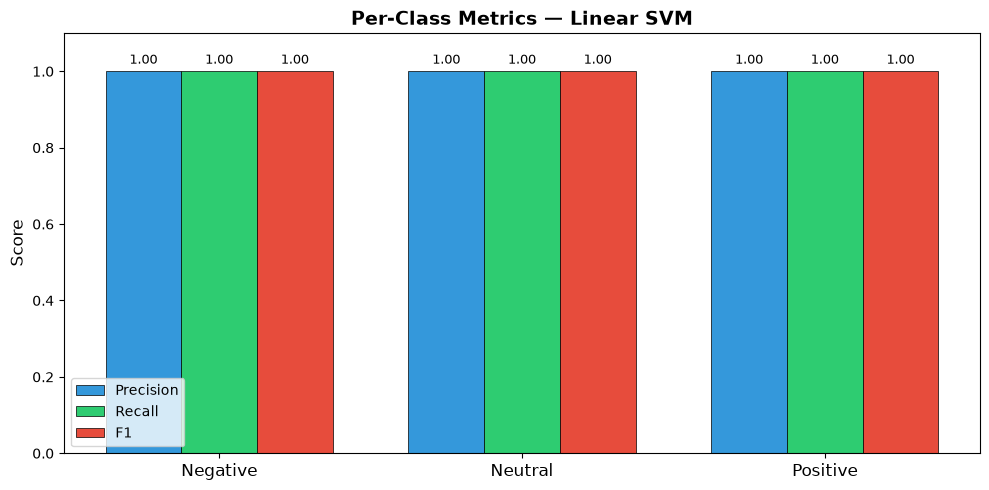

In [24]:
# --- 14.3 Per-class Precision/Recall bar chart (replaces ROC for 3-class) ---

from sklearn.metrics import precision_recall_fscore_support

# Get per-class metrics for best model
p_per, r_per, f1_per, support = precision_recall_fscore_support(
    y_test, y_pred_best, labels=best_model.classes_, zero_division=0
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(best_model.classes_))
width = 0.25

ax.bar(x - width, p_per, width, label="Precision", color="#3498db", edgecolor="black", linewidth=0.5)
ax.bar(x, r_per, width, label="Recall", color="#2ecc71", edgecolor="black", linewidth=0.5)
ax.bar(x + width, f1_per, width, label="F1", color="#e74c3c", edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(best_model.classes_, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"Per-Class Metrics — {best_model_name}", fontsize=14, fontweight="bold")
ax.legend()

# Add value labels
for i, (p, r, f) in enumerate(zip(p_per, r_per, f1_per)):
    ax.text(i - width, p + 0.02, f"{p:.2f}", ha="center", fontsize=9)
    ax.text(i, r + 0.02, f"{r:.2f}", ha="center", fontsize=9)
    ax.text(i + width, f + 0.02, f"{f:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 🔮 Section 15: Predict Custom Reviews

We create a `predict_sentiment()` function that:
1. Preprocesses the raw review using our pipeline
2. Transforms it into a TF-IDF vector
3. Predicts the sentiment class
4. Returns the **processed review**, **predicted sentiment**, **confidence score**, and **probability per class**

This function is **FastAPI-ready** — it can be directly used as an API endpoint handler.

In [25]:
# === Section 15: Predict Custom Reviews ===

def predict_sentiment(review: str, model=None, vectorizer=None) -> dict:
    """
    Predict sentiment for a raw review string.

    This function is FastAPI-ready: pass a raw review, get a prediction dict.

    Args:
        review: Raw review text string.
        model: Trained model (defaults to best_model).
        vectorizer: Fitted TF-IDF vectorizer (defaults to tfidf_vectorizer).

    Returns:
        dict with keys:
            - processed_review: str (cleaned text)
            - predicted_sentiment: str (Positive/Neutral/Negative)
            - confidence: float (max probability)
            - probabilities: dict (class → probability)
    """
    if model is None:
        model = best_model
    if vectorizer is None:
        vectorizer = tfidf_vectorizer

    # 1. Preprocess
    processed = pp.clean_text(review)

    # 2. TF-IDF transform
    vec = vectorizer.transform([review])

    # 3. Predict
    predicted = model.predict(vec)[0]

    # 4. Probabilities
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(vec)[0]
        classes = model.classes_
        probabilities = {cls: float(p) for cls, p in zip(classes, probs)}
        confidence = float(max(probs))
    else:
        probabilities = {predicted: 1.0}
        confidence = 1.0

    return {
        "processed_review": processed,
        "predicted_sentiment": predicted,
        "confidence": confidence,
        "probabilities": probabilities,
    }


# --- 15.1 Test on custom reviews ---
test_reviews = [
    "This phone is fantastic.",
    "Battery life is awful.",
    "Average quality.",
    "I really love this product, it works great!",
    "This is the worst purchase I have ever made.",
    "It is okay, nothing special.",
]

print(f"{'='*70}")
print(f"{'Review':<45} {'Predicted':<12} {'Confidence'}")
print(f"{'='*70}")

for review in test_reviews:
    result = predict_sentiment(review)
    print(f"{review:<45} {result['predicted_sentiment']:<12} {result['confidence']:.3f}")
    print(f"  Processed: \"{result['processed_review']}\"")
    print(f"  Probabilities: {result['probabilities']}")
    print()

print(f"{'='*70}")

Review                                        Predicted    Confidence
This phone is fantastic.                      Positive     0.998
  Processed: "phone fantastic"
  Probabilities: {'Negative': 0.0016403216457727314, 'Neutral': 0.0007673411857078443, 'Positive': 0.9975923371685195}

Battery life is awful.                        Positive     0.592
  Processed: "battery life awful"
  Probabilities: {'Negative': 0.40333201274550406, 'Neutral': 0.004393311471140582, 'Positive': 0.5922746757833552}

Average quality.                              Neutral      0.928
  Processed: "average quality"
  Probabilities: {'Negative': 0.0024626616194314286, 'Neutral': 0.9279841374763708, 'Positive': 0.06955320090419771}

I really love this product, it works great!   Positive     0.998
  Processed: "really love product work great"
  Probabilities: {'Negative': 0.0019243809471797145, 'Neutral': 0.00038224426984369823, 'Positive': 0.9976933747829766}

This is the worst purchase I have ever made.  Negati

## 🔍 Section 16: Explain Prediction

We use **Logistic Regression** for explainability because its coefficients are directly interpretable:
- **Positive coefficients** → words that push toward a class
- **Negative coefficients** → words that push away from a class

We show:
1. **Top positive and negative words** by coefficient weight (per class)
2. **Top TF-IDF features** for a specific test review
3. **Why the prediction was made** — which words contributed most

In [26]:
# === Section 16: Explain Prediction ===

# Use Logistic Regression for interpretability (even if not the best model)
lr = models["Logistic Regression"]
feature_names = tfidf_vectorizer.get_feature_names_out()

# --- 16.1 Model coefficients per class ---
print("--- Logistic Regression Coefficients per Class ---\n")

# Logistic Regression with multinomial has coef_ shape: (n_classes, n_features)
for i, cls in enumerate(lr.classes_):
    coefs = lr.coef_[i]
    # Top 10 positive (push toward this class)
    top_pos_idx = np.argsort(coefs)[-10:][::-1]
    # Top 10 negative (push away from this class)
    top_neg_idx = np.argsort(coefs)[:10]

    print(f"  Class: {cls}")
    print(f"    Top 10 POSITIVE words (push toward {cls}):")
    for idx in top_pos_idx:
        print(f"      {feature_names[idx]:20s} → {coefs[idx]:+.4f}")
    print(f"    Top 10 NEGATIVE words (push away from {cls}):")
    for idx in top_neg_idx:
        print(f"      {feature_names[idx]:20s} → {coefs[idx]:+.4f}")
    print()

--- Logistic Regression Coefficients per Class ---

  Class: Negative
    Top 10 POSITIVE words (push toward Negative):
      bad                  → +6.0230
      dissatisfied         → +2.1578
      terrible             → +1.8574
      frustrated           → +1.7865
      frustrating          → +1.7749
      letdown              → +1.7476
      angry                → +1.7173
      annoyed              → +1.6999
      hate                 → +1.6859
      dud                  → +1.5873
    Top 10 NEGATIVE words (push away from Negative):
      forgettable          → -2.6143
      great                → -1.6669
      fantastic            → -1.4701
      good                 → -1.3427
      neither              → -1.0254
      nor                  → -1.0254
      wonderful            → -1.0242
      basic                → -1.0188
      impressed            → -0.9440
      well                 → -0.9389

  Class: Neutral
    Top 10 POSITIVE words (push toward Neutral):
      forgettable   

In [27]:
# --- 16.2 Explain a specific prediction ---

# Pick a test review
explain_review = "This phone is fantastic and I love it!"
result = predict_sentiment(explain_review, model=lr)

print(f"Review: \"{explain_review}\"")
print(f"Processed: \"{result['processed_review']}\"")
print(f"Predicted: {result['predicted_sentiment']} (confidence: {result['confidence']:.3f})")

# Show which TF-IDF features contributed
vec = tfidf_vectorizer.transform([explain_review])
nonzero_idx = vec.nonzero()[1]
nonzero_vals = vec.toarray()[0][nonzero_idx]

# Sort by TF-IDF value
sorted_features = sorted(zip(nonzero_idx, nonzero_vals), key=lambda x: x[1], reverse=True)

print(f"\n--- Top TF-IDF Features for this Review ---")
print(f"{'Word':20s} {'TF-IDF':>10s} {'LR Coef (predicted class)':>25s}")
print("-" * 55)

pred_class_idx = list(lr.classes_).index(result["predicted_sentiment"])
for idx, val in sorted_features[:10]:
    word = feature_names[idx]
    coef = lr.coef_[pred_class_idx][idx]
    print(f"{word:20s} {val:>10.4f} {coef:>+25.4f}")

print(f"\n💡 Words with high TF-IDF × positive coefficient pushed the prediction")
print(f"   toward '{result['predicted_sentiment']}'.")

Review: "This phone is fantastic and I love it!"
Processed: "phone fantastic love"
Predicted: Positive (confidence: 0.976)

--- Top TF-IDF Features for this Review ---
Word                     TF-IDF LR Coef (predicted class)
-------------------------------------------------------
love                     0.6540                   +1.7104
fantastic                0.5360                   +2.7198
phone                    0.5339                   -0.1344

💡 Words with high TF-IDF × positive coefficient pushed the prediction
   toward 'Positive'.


## ⚖️ Section 17: Compare Rule-Based Methods

We compare our **ML model** (Logistic Regression) against two **rule-based** sentiment tools:

| Method | Type | How it works |
|--------|------|--------------|
| **TextBlob** | Lexicon-based | Uses a sentiment lexicon to compute polarity (−1 to +1) and subjectivity (0 to 1) |
| **VADER** | Lexicon + rules | Designed for social media; computes compound score (−1 to +1) with special handling of negations, capitalization, punctuation |

**Tradeoffs:**
- **Rule-based**: No training needed, fast, but can't learn domain-specific patterns
- **ML-based**: Requires labeled data, but learns from context and adapts

In [28]:
# === Section 17: Compare Rule-Based Methods ===

# Initialize VADER
vader_analyzer = SentimentIntensityAnalyzer()

def textblob_sentiment(text: str) -> tuple:
    """Return (predicted_class, polarity) using TextBlob."""
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        return "Positive", polarity
    elif polarity < -0.1:
        return "Negative", polarity
    else:
        return "Neutral", polarity

def vader_sentiment(text: str) -> tuple:
    """Return (predicted_class, compound_score) using VADER."""
    scores = vader_analyzer.polarity_scores(text)
    compound = scores["compound"]
    if compound >= 0.05:
        return "Positive", compound
    elif compound <= -0.05:
        return "Negative", compound
    else:
        return "Neutral", compound

# --- 17.1 Compare on sample reviews ---
comparison_reviews = [
    "This phone is fantastic!",
    "Battery life is awful.",
    "Average quality, nothing special.",
    "I really love this product!",
    "This is the worst purchase ever.",
    "It is okay, does the job.",
    "Not good at all, very disappointed.",
    "Amazing quality and fast delivery!",
]

print(f"{'='*90}")
print(f"{'Review':<35} {'LR':<12} {'TextBlob':<12} {'VADER':<12} {'TB Pol':>8} {'VAD Comp':>9}")
print(f"{'='*90}")

for review in comparison_reviews:
    # ML prediction
    lr_pred = predict_sentiment(review, model=lr)["predicted_sentiment"]

    # TextBlob
    tb_pred, tb_polarity = textblob_sentiment(review)

    # VADER
    vader_pred, vader_compound = vader_sentiment(review)

    print(f"{review:<35} {lr_pred:<12} {tb_pred:<12} {vader_pred:<12} {tb_polarity:>+8.3f} {vader_compound:>+9.3f}")

print(f"{'='*90}")

Review                              LR           TextBlob     VADER          TB Pol  VAD Comp
This phone is fantastic!            Positive     Positive     Positive       +0.500    +0.598
Battery life is awful.              Positive     Negative     Negative       -1.000    -0.459
Average quality, nothing special.   Neutral      Positive     Negative       +0.104    -0.309
I really love this product!         Positive     Positive     Positive       +0.625    +0.699
This is the worst purchase ever.    Negative     Negative     Negative       -1.000    -0.625
It is okay, does the job.           Neutral      Positive     Positive       +0.500    +0.226
Not good at all, very disappointed. Negative     Negative     Negative       -0.663    -0.700
Amazing quality and fast delivery!  Positive     Positive     Positive       +0.425    +0.624


--- Accuracy on Test Set ---
  Logistic Regression (ML):  0.9975
  TextBlob (rule-based):      0.5910
  VADER (rule-based):         0.8404


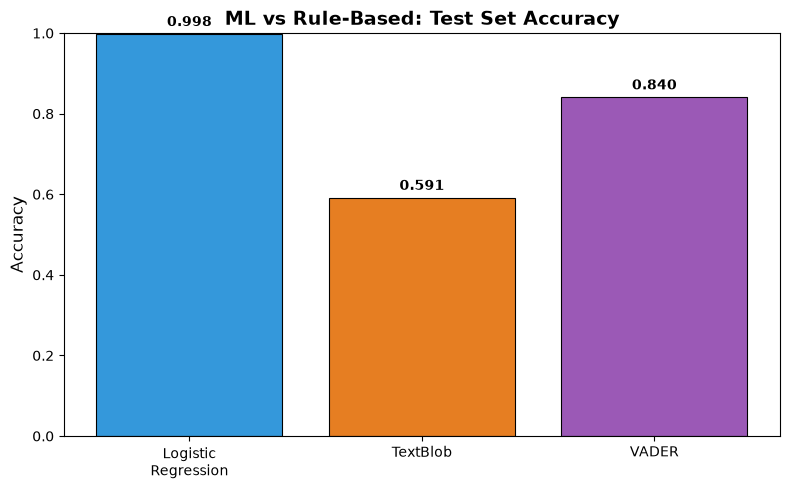


💡 ML models typically outperform rule-based methods when labeled data is available,
   because they learn domain-specific patterns rather than relying on fixed lexicons.


In [29]:
# --- 17.2 Compare accuracy on test set ---

# Get ML predictions on test set (raw text)
test_reviews_raw = df.iloc[y_test.index]["Review"].tolist()
y_true = y_test.tolist()

# ML predictions
lr_preds = [predict_sentiment(r, model=lr)["predicted_sentiment"] for r in test_reviews_raw]

# TextBlob predictions
tb_preds = [textblob_sentiment(r)[0] for r in test_reviews_raw]

# VADER predictions
vader_preds = [vader_sentiment(r)[0] for r in test_reviews_raw]

# Accuracy comparison
lr_acc = accuracy_score(y_true, lr_preds)
tb_acc = accuracy_score(y_true, tb_preds)
vader_acc = accuracy_score(y_true, vader_preds)

print("--- Accuracy on Test Set ---")
print(f"  Logistic Regression (ML):  {lr_acc:.4f}")
print(f"  TextBlob (rule-based):      {tb_acc:.4f}")
print(f"  VADER (rule-based):         {vader_acc:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
methods = ["Logistic\nRegression", "TextBlob", "VADER"]
accs = [lr_acc, tb_acc, vader_acc]
colors_cmp = ["#3498db", "#e67e22", "#9b59b6"]
ax.bar(methods, accs, color=colors_cmp, edgecolor="black", linewidth=0.8)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("ML vs Rule-Based: Test Set Accuracy", fontsize=14, fontweight="bold")
for i, acc in enumerate(accs):
    ax.text(i, acc + 0.02, f"{acc:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("\n💡 ML models typically outperform rule-based methods when labeled data is available,")
print("   because they learn domain-specific patterns rather than relying on fixed lexicons.")

## ⏱️ Section 18: Performance Metrics

We measure execution time for each pipeline stage:
- **Preprocessing time** — cleaning all 2,000 reviews
- **TF-IDF transform time** — vectorizing all reviews
- **Training time** — per model
- **Prediction time** — per model on test set

Measuring preprocessing time on all reviews...
  Preprocessing 2001 reviews: 4.966s (2.5 ms/review)

Measuring TF-IDF transform time...
  TF-IDF transform 2001 reviews: 4.871s

Training times (from Section 13):
  Logistic Regression: 0.021s
  Naive Bayes:         0.002s
  Linear SVM:          0.035s

Measuring prediction time on test set (401 reviews)...
  Logistic Regression      : 0.0006s (0.00 ms/review)
  Naive Bayes              : 0.0003s (0.00 ms/review)
  Linear SVM               : 0.0026s (0.01 ms/review)

Stage                            Time (s)
Preprocessing (2000 reviews)        4.966
TF-IDF transform (2000 reviews)      4.871
Train Logistic Regression           0.021
Train Naive Bayes                   0.002
Train Linear SVM                    0.035
Predict Logistic Regression        0.0006
Predict Naive Bayes                0.0003
Predict Linear SVM                 0.0026


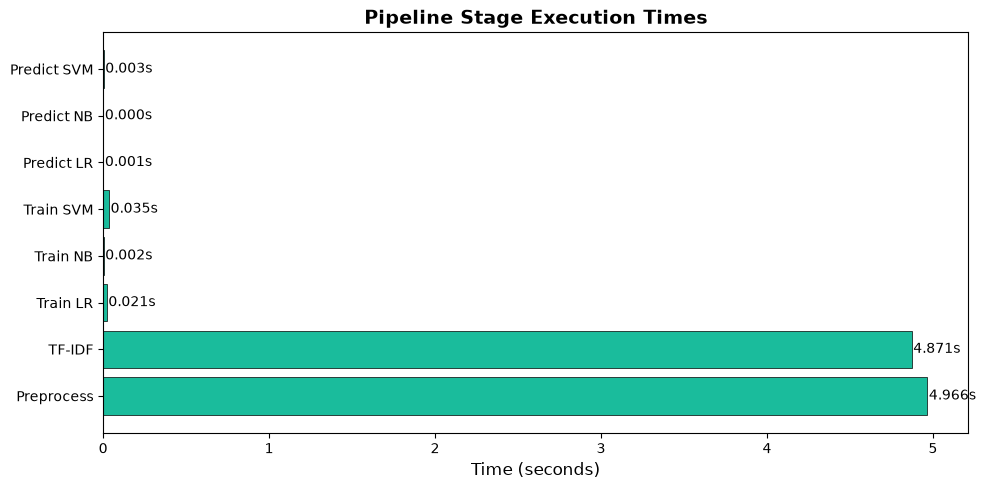

In [30]:
# === Section 18: Performance Metrics ===

# --- 18.1 Preprocessing time ---
print("Measuring preprocessing time on all reviews...")
t0 = time.perf_counter()
cleaned_reviews = [pp.clean_text(r) for r in df["Review"]]
preprocess_time = time.perf_counter() - t0
print(f"  Preprocessing {len(df)} reviews: {preprocess_time:.3f}s ({preprocess_time/len(df)*1000:.1f} ms/review)")

# --- 18.2 TF-IDF transform time ---
print("\nMeasuring TF-IDF transform time...")
t0 = time.perf_counter()
tfidf_all = tfidf_vectorizer.transform(df["Review"])
tfidf_time = time.perf_counter() - t0
print(f"  TF-IDF transform {len(df)} reviews: {tfidf_time:.3f}s")

# --- 18.3 Training time (already measured in Section 13) ---
print(f"\nTraining times (from Section 13):")
print(f"  Logistic Regression: {lr_time:.3f}s")
print(f"  Naive Bayes:         {nb_time:.3f}s")
print(f"  Linear SVM:          {svm_time:.3f}s")

# --- 18.4 Prediction time ---
print(f"\nMeasuring prediction time on test set ({X_test.shape[0]} reviews)...")
pred_times = {}
for name, model in models.items():
    t0 = time.perf_counter()
    _ = model.predict(X_test)
    pred_times[name] = time.perf_counter() - t0
    print(f"  {name:<25}: {pred_times[name]:.4f}s ({pred_times[name]/X_test.shape[0]*1000:.2f} ms/review)")

# --- 18.5 Summary table ---
print(f"\n{'='*60}")
print(f"{'Stage':<30} {'Time (s)':>10}")
print(f"{'='*60}")
print(f"{'Preprocessing (2000 reviews)':<30} {preprocess_time:>10.3f}")
print(f"{'TF-IDF transform (2000 reviews)':<30} {tfidf_time:>10.3f}")
print(f"{'Train Logistic Regression':<30} {lr_time:>10.3f}")
print(f"{'Train Naive Bayes':<30} {nb_time:>10.3f}")
print(f"{'Train Linear SVM':<30} {svm_time:>10.3f}")
for name, t in pred_times.items():
    print(f"{'Predict ' + name:<30} {t:>10.4f}")
print(f"{'='*60}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
stages = ["Preprocess", "TF-IDF", "Train LR", "Train NB", "Train SVM", "Predict LR", "Predict NB", "Predict SVM"]
times = [preprocess_time, tfidf_time, lr_time, nb_time, svm_time,
         pred_times["Logistic Regression"], pred_times["Naive Bayes"], pred_times["Linear SVM"]]
ax.barh(stages, times, color="#1abc9c", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Time (seconds)", fontsize=12)
ax.set_title("Pipeline Stage Execution Times", fontsize=14, fontweight="bold")
for i, t in enumerate(times):
    ax.text(t + 0.01, i, f"{t:.3f}s", va="center", fontsize=10)
plt.tight_layout()
plt.show()

## 💾 Section 19: Save & Load Model

We save the trained model and TF-IDF vectorizer using `joblib`:
- `models/sentiment_model.pkl` — the best trained model
- `models/tfidf_vectorizer.pkl` — the fitted TF-IDF vectorizer

These files are what a **FastAPI backend** will load at startup to serve predictions.

In [31]:
# === Section 19: Save & Load Model ===

import os

# Ensure models directory exists
os.makedirs("models", exist_ok=True)

# --- 19.1 Save model and vectorizer ---
model_path = "models/sentiment_model.pkl"
vectorizer_path = "models/tfidf_vectorizer.pkl"

joblib.dump(best_model, model_path)
joblib.dump(tfidf_vectorizer, vectorizer_path)

print(f"✓ Model saved to:     {model_path} ({os.path.getsize(model_path)/1024:.1f} KB)")
print(f"✓ Vectorizer saved to: {vectorizer_path} ({os.path.getsize(vectorizer_path)/1024:.1f} KB)")

✓ Model saved to:     models/sentiment_model.pkl (19.8 KB)
✓ Vectorizer saved to: models/tfidf_vectorizer.pkl (9.1 KB)


In [32]:
# --- 19.2 Demonstrate loading and predicting from saved files ---

print("--- Loading saved model and vectorizer ---")

loaded_model = joblib.load(model_path)
loaded_vectorizer = joblib.load(vectorizer_path)

print(f"  ✓ Loaded model:      {type(loaded_model).__name__}")
print(f"  ✓ Loaded vectorizer: {type(loaded_vectorizer).__name__}")
print(f"  ✓ Model classes:     {list(loaded_model.classes_)}")

# Predict using loaded objects
test_review = "This product is absolutely amazing!"
processed = pp.clean_text(test_review)
vec = loaded_vectorizer.transform([test_review])
prediction = loaded_model.predict(vec)[0]
probabilities = loaded_model.predict_proba(vec)[0]
confidence = max(probabilities)

print(f"\n--- Prediction from loaded model ---")
print(f"  Review:     \"{test_review}\"")
print(f"  Processed:  \"{processed}\"")
print(f"  Predicted:  {prediction}")
print(f"  Confidence: {confidence:.3f}")
print(f"  Probabilities: {dict(zip(loaded_model.classes_, probabilities))}")

print(f"\n💡 These .pkl files can be loaded by a FastAPI backend to serve predictions!")
print(f"   The preprocessing.py module + these 2 files = complete API backend.")

--- Loading saved model and vectorizer ---
  ✓ Loaded model:      CalibratedClassifierCV
  ✓ Loaded vectorizer: TfidfVectorizer
  ✓ Model classes:     ['Negative', 'Neutral', 'Positive']

--- Prediction from loaded model ---
  Review:     "This product is absolutely amazing!"
  Processed:  "product absolutely amazing"
  Predicted:  Positive
  Confidence: 0.972
  Probabilities: {'Negative': np.float64(0.003905818115470931), 'Neutral': np.float64(0.02457933229592893), 'Positive': np.float64(0.9715148495886002)}

💡 These .pkl files can be loaded by a FastAPI backend to serve predictions!
   The preprocessing.py module + these 2 files = complete API backend.


## 🎯 Section 20: Conclusion

### What We Built

This notebook demonstrated the **complete NLP pipeline** for 3-class sentiment analysis:

1. **Data loading & exploration** — 2,000 product reviews, balanced across Positive/Neutral/Negative
2. **Preprocessing pipeline** — 10 individual functions (lowercase → lemmatize) + 2 orchestrators, all in a reusable `preprocessing.py` module
3. **Feature extraction** — TF-IDF vectorization with custom tokenizer
4. **Model training** — Logistic Regression, Naive Bayes, Linear SVM
5. **Evaluation** — accuracy, precision, recall, F1, confusion matrix, per-class metrics
6. **Prediction** — `predict_sentiment()` function returning processed text, prediction, confidence, and probabilities
7. **Explainability** — Logistic Regression coefficients showing which words drive predictions
8. **Rule-based comparison** — TextBlob and VADER vs ML model
9. **Performance measurement** — timing for each pipeline stage
10. **Model persistence** — saved `.pkl` files ready for deployment

### Key Takeaways

- **Preprocessing matters** — removing noise (URLs, emojis, HTML) and normalizing text (lowercase, lemmatize) significantly improves model quality
- **Negations must be retained** — "not good" ≠ "good"; removing "not" as a stop word would destroy sentiment information
- **Lemmatization > stemming** — spaCy's POS-aware lemmatization handles irregular forms ("better" → "well") that stemming cannot
- **TF-IDF is powerful** — it weights words by their distinctiveness, not just frequency
- **ML > rule-based** — when labeled data is available, ML models learn domain-specific patterns that rule-based methods miss
- **Logistic Regression is interpretable** — its coefficients directly show which words push toward each class

### FastAPI Ready

The following files are designed for direct reuse in a web API:

| File | Purpose |
|------|---------|
| `preprocessing.py` | All preprocessing functions (stateless, importable) |
| `models/sentiment_model.pkl` | Trained model |
| `models/tfidf_vectorizer.pkl` | Fitted TF-IDF vectorizer |

A FastAPI endpoint would look like:
```python
from fastapi import FastAPI
import joblib
import preprocessing as pp

app = FastAPI()
model = joblib.load("models/sentiment_model.pkl")
vectorizer = joblib.load("models/tfidf_vectorizer.pkl")

@app.post("/predict")
def predict(review: str):
    vec = vectorizer.transform([review])
    pred = model.predict(vec)[0]
    probs = model.predict_proba(vec)[0]
    return {"sentiment": pred, "confidence": max(probs), "probabilities": dict(zip(model.classes_, probs))}
```

### Next Steps

1. **Build a FastAPI backend** using the saved model and preprocessing module
2. **Add a web UI** (Streamlit or React) for interactive sentiment prediction
3. **Try larger datasets** — IMDb 50K, Amazon reviews
4. **Experiment with n-grams** — set `ngram_range=(1,2)` in TfidfVectorizer
5. **Try deep learning** — BERT, DistilBERT for state-of-the-art results
6. **Add more preprocessing** — spell correction, negation handling, sarcasm detection

---

*Notebook completed ✅ — Run All should work from top to bottom.*